In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 1. Data Loading
Pada langkah ini, dataset CAD Alizadeh dibaca dari file Excel ke dalam DataFrame bernama `df`. DataFrame ini menjadi sumber data utama untuk proses klasifikasi pada langkah berikutnya.

In [3]:
df = pd.read_excel('CADalizadeh.xls')

## 1.1 Visualisasi Awal Data
Pada tahap awal ini, data divisualisasikan untuk melihat distribusi kelas target dan jumlah nilai hilang pada setiap kolom. Visualisasi ini penting agar kita memahami kondisi data sebelum masuk ke tahap preprocessing dan pemodelan.

C:\Users\Muflih Rafif\AppData\Local\Temp\ipykernel_28744\645312690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


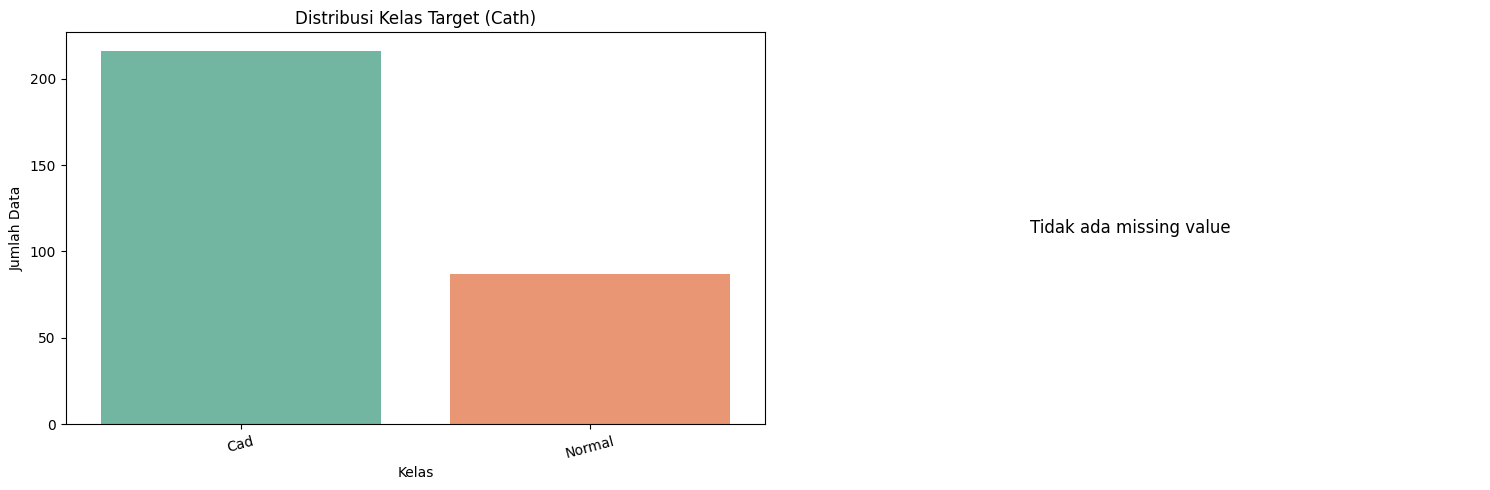

In [4]:
candidate_targets = ["Class", "class", "target", "label", "diagnosis", "Class Label"]
visual_target_col = next((c for c in candidate_targets if c in df.columns), df.columns[-1])
visual_df = df.dropna(subset=[visual_target_col]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(
    data=visual_df,
    x=visual_target_col,
    order=visual_df[visual_target_col].value_counts().index,
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title(f"Distribusi Kelas Target ({visual_target_col})")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Data")
axes[0].tick_params(axis="x", rotation=15)

missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
if missing_counts.empty:
    axes[1].text(0.5, 0.5, "Tidak ada missing value", ha="center", va="center", fontsize=12)
    axes[1].set_axis_off()
else:
    sns.barplot(x=missing_counts.index, y=missing_counts.values, ax=axes[1], palette="crest")
    axes[1].set_title("Jumlah Missing Value per Kolom")
    axes[1].set_xlabel("Kolom")
    axes[1].set_ylabel("Jumlah Missing")
    axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 2. Split Data (Train/Test)
Pada langkah ini dilakukan persiapan data sebelum pemodelan.
1. Menentukan kolom target secara otomatis dari beberapa kandidat nama kolom.
2. Memisahkan fitur (`X`) dan target (`y`).
3. Membersihkan nilai hilang pada fitur.
4. Mengubah fitur kategorikal menjadi numerik dengan one-hot encoding.
5. Membagi data menjadi data latih (80%) dan data uji (20%) menggunakan `stratify` agar proporsi kelas tetap seimbang.

In [5]:
candidate_targets = ["Class", "class", "target", "label", "diagnosis", "Class Label"]
target_col = next((c for c in candidate_targets if c in df.columns), df.columns[-1])

# Memisahkan fitur dan target
df = df.dropna(subset=[target_col]).copy()
X = df.drop(columns=[target_col])
y = df[target_col]

# Mengganti penanda missing value yang umum pada dataset ini
X = X.replace("?", np.nan)

# Mengisi missing value: numerik dengan median, kategorikal dengan modus
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode(dropna=True)[0])
    else:
        X[col] = X[col].fillna(X[col].median())

# Mengubah kategori menjadi fitur numerik
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kolom target yang digunakan: {target_col}")
print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji  : {len(X_test)}")
print(f"Jumlah fitur setelah encoding: {X.shape[1]}")

Kolom target yang digunakan: Cath
Jumlah data latih: 242
Jumlah data uji  : 61
Jumlah fitur setelah encoding: 56


## 3. Klasifikasi Naive Bayes
Pada langkah ini model `GaussianNB` dibuat dan dilatih menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model digunakan untuk memprediksi kelas pada data uji sehingga dihasilkan `y_pred_nb`. Hasil ini akan dipakai sebagai pembanding untuk Random Forest.

In [6]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)
print("Model Naive Bayes selesai dilatih dan prediksi telah dibuat.")

Model Naive Bayes selesai dilatih dan prediksi telah dibuat.


## 4. Klasifikasi Random Forest
Pada langkah ini model `RandomForestClassifier` dibuat dan dilatih menggunakan data latih (`X_train`, `y_train`). Random Forest memakai banyak decision tree, lalu menggabungkan hasilnya untuk membuat prediksi yang biasanya lebih stabil dibandingkan model tunggal.

In [7]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
print("Model Random Forest selesai dilatih dan prediksi telah dibuat.")

Model Random Forest selesai dilatih dan prediksi telah dibuat.


## 5. Evaluasi Performansi dan Perbandingan
Pada langkah ini performa kedua model dinilai menggunakan data uji.
Metrik yang dihitung adalah Accuracy, Precision, Recall, dan F1-Score (weighted), lalu ditampilkan juga Confusion Matrix serta Classification Report untuk melihat performa per kelas. Hasil Random Forest kemudian dibandingkan langsung dengan Naive Bayes.

In [8]:
def hitung_metrik(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

hasil_nb = hitung_metrik(y_test, y_pred_nb)
hasil_rf = hitung_metrik(y_test, y_pred_rf)

hasil_perbandingan = pd.DataFrame([hasil_nb, hasil_rf], index=["Naive Bayes", "Random Forest"])
print("=== Perbandingan Performa Model ===")
print(hasil_perbandingan)

print("\n=== Confusion Matrix Naive Bayes ===")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report Naive Bayes:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

print("\n=== Confusion Matrix Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report Random Forest:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

model_terbaik = hasil_perbandingan["F1-Score"].idxmax()
print(f"\nModel dengan F1-Score terbaik: {model_terbaik}")

=== Perbandingan Performa Model ===
               Accuracy  Precision    Recall  F1-Score
Naive Bayes    0.737705   0.783246  0.737705  0.748099
Random Forest  0.836066   0.835731  0.836066  0.825018

=== Confusion Matrix Naive Bayes ===
[[31 12]
 [ 4 14]]

Classification Report Naive Bayes:
              precision    recall  f1-score   support

         Cad       0.89      0.72      0.79        43
      Normal       0.54      0.78      0.64        18

    accuracy                           0.74        61
   macro avg       0.71      0.75      0.72        61
weighted avg       0.78      0.74      0.75        61


=== Confusion Matrix Random Forest ===
[[41  2]
 [ 8 10]]

Classification Report Random Forest:
              precision    recall  f1-score   support

         Cad       0.84      0.95      0.89        43
      Normal       0.83      0.56      0.67        18

    accuracy                           0.84        61
   macro avg       0.84      0.75      0.78        61
weighted a

## 6. Kesimpulan
Berdasarkan hasil klasifikasi pada dataset CAD Alizadeh, Random Forest dan Naive Bayes sama-sama mampu melakukan prediksi kelas, tetapi performanya dibandingkan menggunakan accuracy, precision, recall, dan F1-score.
Dari tabel perbandingan, model dengan F1-score tertinggi dapat dianggap sebagai model terbaik untuk data ini. Pada umumnya Random Forest cenderung memberikan hasil yang lebih baik karena mampu menangkap pola hubungan antar fitur dengan lebih fleksibel dibandingkan Naive Bayes.
Jadi, jika hasil evaluasi menunjukkan Random Forest unggul, maka model tersebut lebih disarankan untuk klasifikasi CAD Alizadeh pada pembagian data yang digunakan di notebook ini.
